The code below uses Monte-Carlo samples from the truncated Gaussian distribution mentioned in the report, and confirms that the squared norm of these samples closely follows a chi-squared distribution

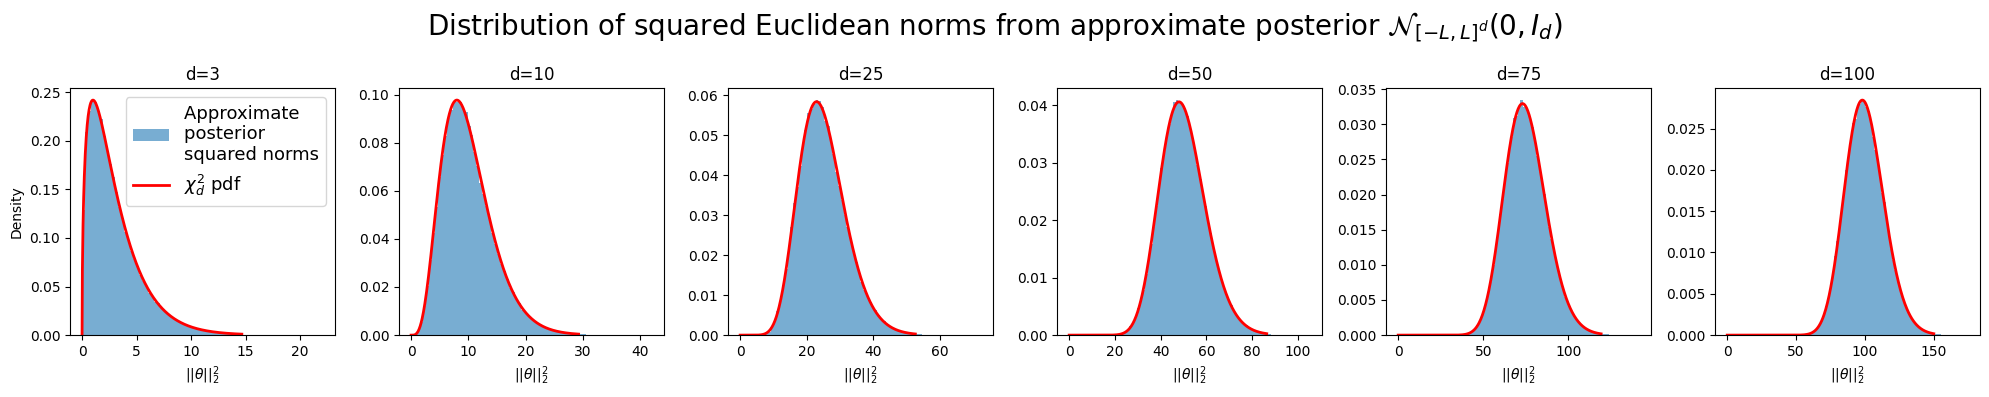

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

def get_spherical_confidence_region(d, p=0.99):
    # Return the R such that a MVN(0,I_d) vector is contained in the sphere with radius R w/p p
    R_squared = stats.chi2.ppf(p, d)
    return np.sqrt(R_squared)

def sample_truncated_gaussian(d, L, n_samples):
    # Sample from N(0,I_d) truncated to the hypercube [-L, L]^dusing rejection sampling.
    samples = []
    batch = n_samples

    while len(samples) < n_samples:
        x = np.random.randn(batch, d)
        accepted = x[np.all(np.abs(x) <= L, axis=1)]
        samples.append(accepted)
        if len(np.vstack(samples)) >= n_samples:
            break

    samples = np.vstack(samples)[:n_samples]
    return samples

# dimensions to visualize
dims = [3, 10, 25, 50, 75, 100]

n_samples = 200000

fig, axes = plt.subplots(1, 6, figsize=(20, 4))

for ax, d in zip(axes, dims):

    L = get_spherical_confidence_region(d)

    samples = sample_truncated_gaussian(d, L, n_samples)

    sq_norms = np.sum(samples**2, axis=1)

    # histogram
    ax.hist(sq_norms, bins=80, density=True, alpha=0.6, label="Approximate \nposterior \nsquared norms")

    # true chi^2 pdf
    x = np.linspace(0, np.percentile(sq_norms, 99.9), 500)
    pdf = stats.chi2.pdf(x, df=d)

    ax.plot(x, pdf, linewidth=2, color="red", label=f"$\chi^2_d$ pdf")

    ax.set_title(f"d={d}")
    ax.set_xlabel(r"$||\theta||^2_2$")
    if d == 3:
        ax.legend(fontsize=13)

axes[0].set_ylabel("Density")

plt.suptitle("Distribution of squared Euclidean norms from approximate posterior $\mathcal{N}_{[-L,L]^d}(0, I_d)$", fontsize=20)
plt.tight_layout()
plt.show()